### Enginize Image Detection (Notebook Version)
This notebook cell performs object detection using a pretrained Enginize  (best.pt) model.
What this code does:
- Checks whether the image file exists.
- Runs inference on the image.
- Draws bounding boxes and labels on detected rooms, objects, items,e tc.
- Displays the annotated result inline in the notebook.

This displays the complete output of a model, working as intended.


image 1/1 /home/administrator/repos/yolo-testing/images/kantoor.jpg: 1024x1024 5 bathrooms, 2 corridors, 27 doors, 10 exits, 1 fire hose, 7 rooms, 2 stairs, 9 toiletss, 17 windows, 1421.2ms
Speed: 13.6ms preprocess, 1421.2ms inference, 87.1ms postprocess per image at shape (1, 3, 1024, 1024)


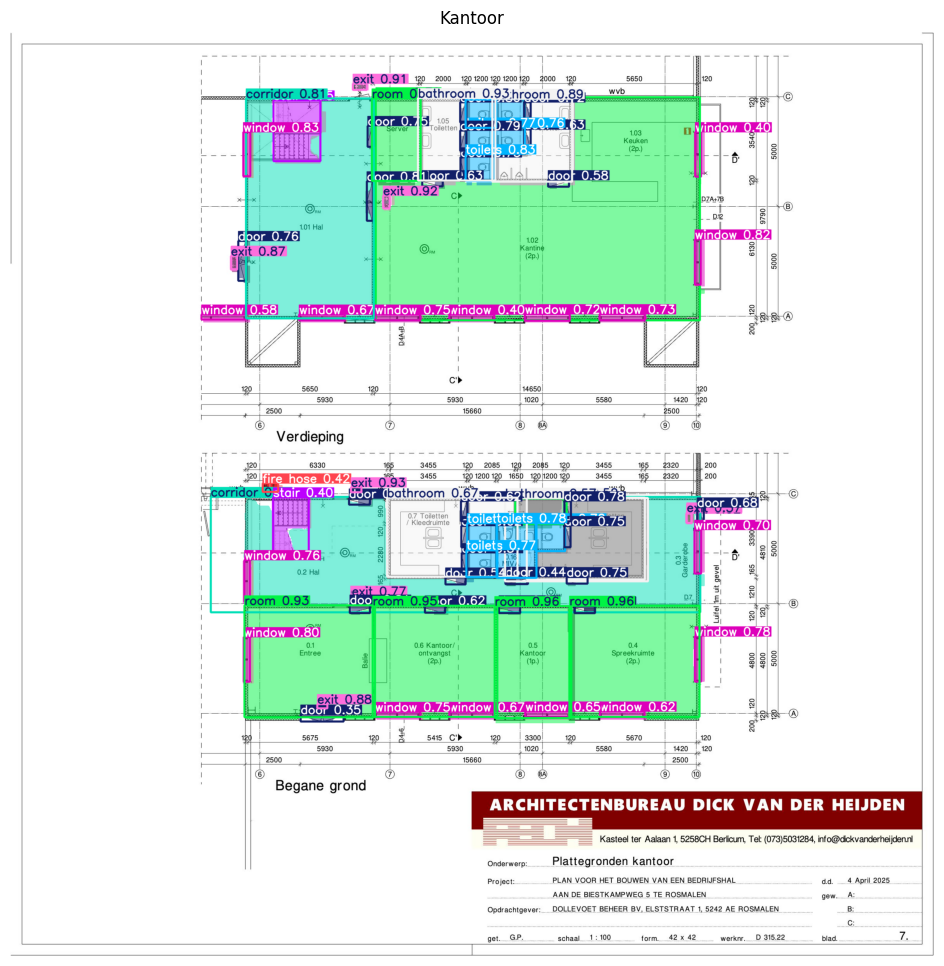

In [2]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

model = YOLO("best.pt")
image_path = Path("images/kantoor.jpg")

#load the image and check if it exists
image_path = Path(image_path)
if not image_path.exists():
    raise FileNotFoundError(f"Image not found: {image_path.resolve()}")

#perform detection
result = model(str(image_path), conf=0.3)[0]

#annotate the image with the results
img = result.plot(line_width=3, font_size=6)

#detect the image and get the annotated result

plt.figure(figsize=(16, 12))  # width, height in inches
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Kantoor")
plt.axis("off")
plt.show()

### Enginze Segmentation

This notebook displays all rooms with segmentation, instead of simple bounding boxes. this will indirectly draw walls around all areas. int this notebook will imgsz parameter also be tested




image 1/1 /home/administrator/repos/yolo-testing/images/kantoor.jpg: 1024x1024 5 bathrooms, 3 corridors, 30 doors, 10 exits, 1 fire hose, 7 rooms, 3 stairs, 9 toiletss, 18 windows, 1357.8ms
Speed: 4.3ms preprocess, 1357.8ms inference, 93.6ms postprocess per image at shape (1, 3, 1024, 1024)


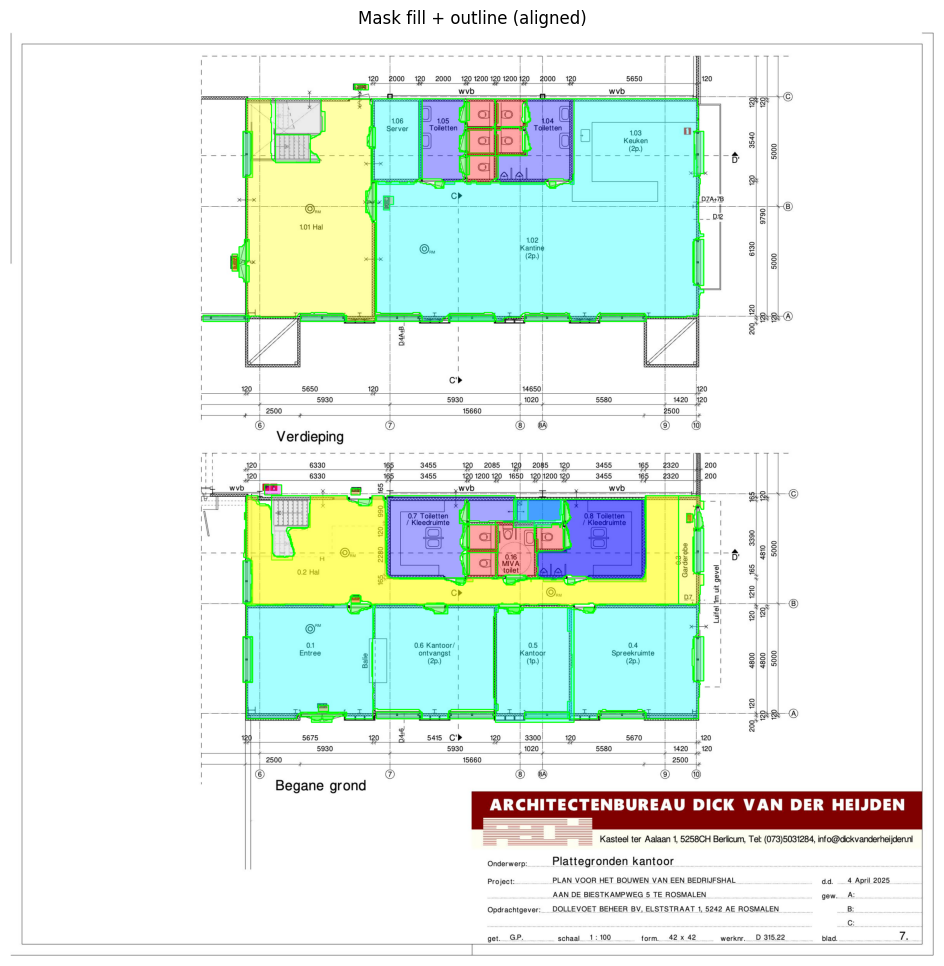

In [24]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

seg_model = YOLO("best.pt")
image_path = Path("images/kantoor.jpg")

def Detect_and_Overlay(image_path: str, conf: float = 0.3, imgsz =1024):
    img = cv2.imread(str(image_path))
    result = seg_model(str(image_path), conf=conf, imgsz=imgsz)[0]
    overlay_img = img.copy()

    # Color map per class name (BGR, because OpenCV uses BGR)
    class_colors = {
        "bathroom":  (255, 0, 0),      # blue
        "corridor":  (0, 255, 255),    # yellow
        "door":      (0, 255, 0),      # green
        "exit":      (0, 128, 255),    # orange
        "fire hose": (255, 0, 255),    # purple
        "room":      (255, 255, 0),    # cyan
        "stairs":    (128, 0, 255),    # violet
        "toilets":   (0, 0, 255),      # red
        "window":    (128, 255, 0),    # light green
    }
    default_color = (200, 200, 200)   # fallback gray
    alpha = 0.35  # transparency for mask fill

    if result.masks is None:
        print("No masks detected.")
    else:
        for i, poly in enumerate(result.masks.xy):
            # Polygon points in original image coords
            pts = np.array(poly, dtype=np.int32).reshape((-1, 1, 2))

            # Get class name and corresponding color
            cls_id = int(result.boxes.cls[i])
            label = result.names[cls_id]
            fill_color_bgr = class_colors.get(label, default_color)

            # 1) Fill on a temp overlay
            temp = overlay_img.copy()
            cv2.fillPoly(temp, [pts], fill_color_bgr)

            # 2) Blend filled region with current image
            overlay_img = cv2.addWeighted(overlay_img, 1 - alpha, temp, alpha, 0)

            # 3) Draw outline on top
            cv2.polylines(overlay_img, [pts], True, (0, 255, 0), 2)
    return overlay_img

plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(Detect_and_Overlay(image_path, 0.2), cv2.COLOR_BGR2RGB))
plt.title("Mask fill + outline (aligned)")
plt.axis("off")
plt.show()

### Testing in 45 degrees, non square rooms

in this we are testing 2 things, the same images as before, but now 45 degrees twisted, and a building with a round element.
this is for testing edge cases.

in this, you can see that the model has more problems in detecting non-square or tilted rooms. since these rooms are a lot less common as "Normal" square rooms, you can see that the model has less training in these models


image 1/1 /home/administrator/repos/yolo-testing/images/kantoor-45 degrees.jpg: 1280x736 2 bathrooms, 6 corridors, 9 doors, 8 exits, 25 rooms, 2 stairs, 9 toiletss, 24 windows, 986.8ms
Speed: 5.1ms preprocess, 986.8ms inference, 87.2ms postprocess per image at shape (1, 3, 1280, 736)


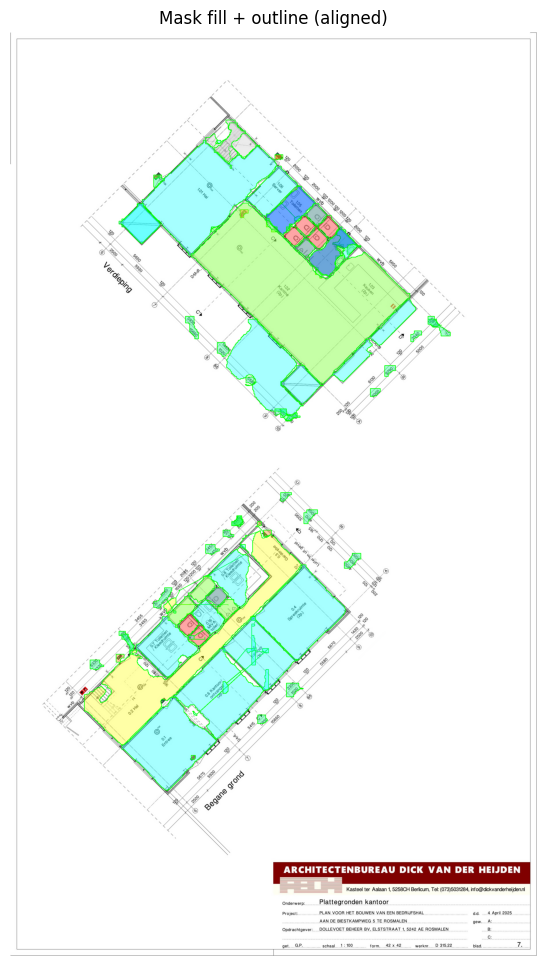

In [18]:
image_path = Path("images/kantoor-45 degrees.jpg")

plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(Detect_and_Overlay(image_path, 0.1, 1280), cv2.COLOR_BGR2RGB))
plt.title("Mask fill + outline (aligned)")
plt.axis("off")
plt.show()

image 1/1 /home/administrator/repos/yolo-testing/images/Rondeel.png: 800x1280 6 bathrooms, 9 corridors, 50 doors, 20 rooms, 5 stairs, 11 toiletss, 1027.1ms
Speed: 6.3ms preprocess, 1027.1ms inference, 99.1ms postprocess per image at shape (1, 3, 800, 1280)


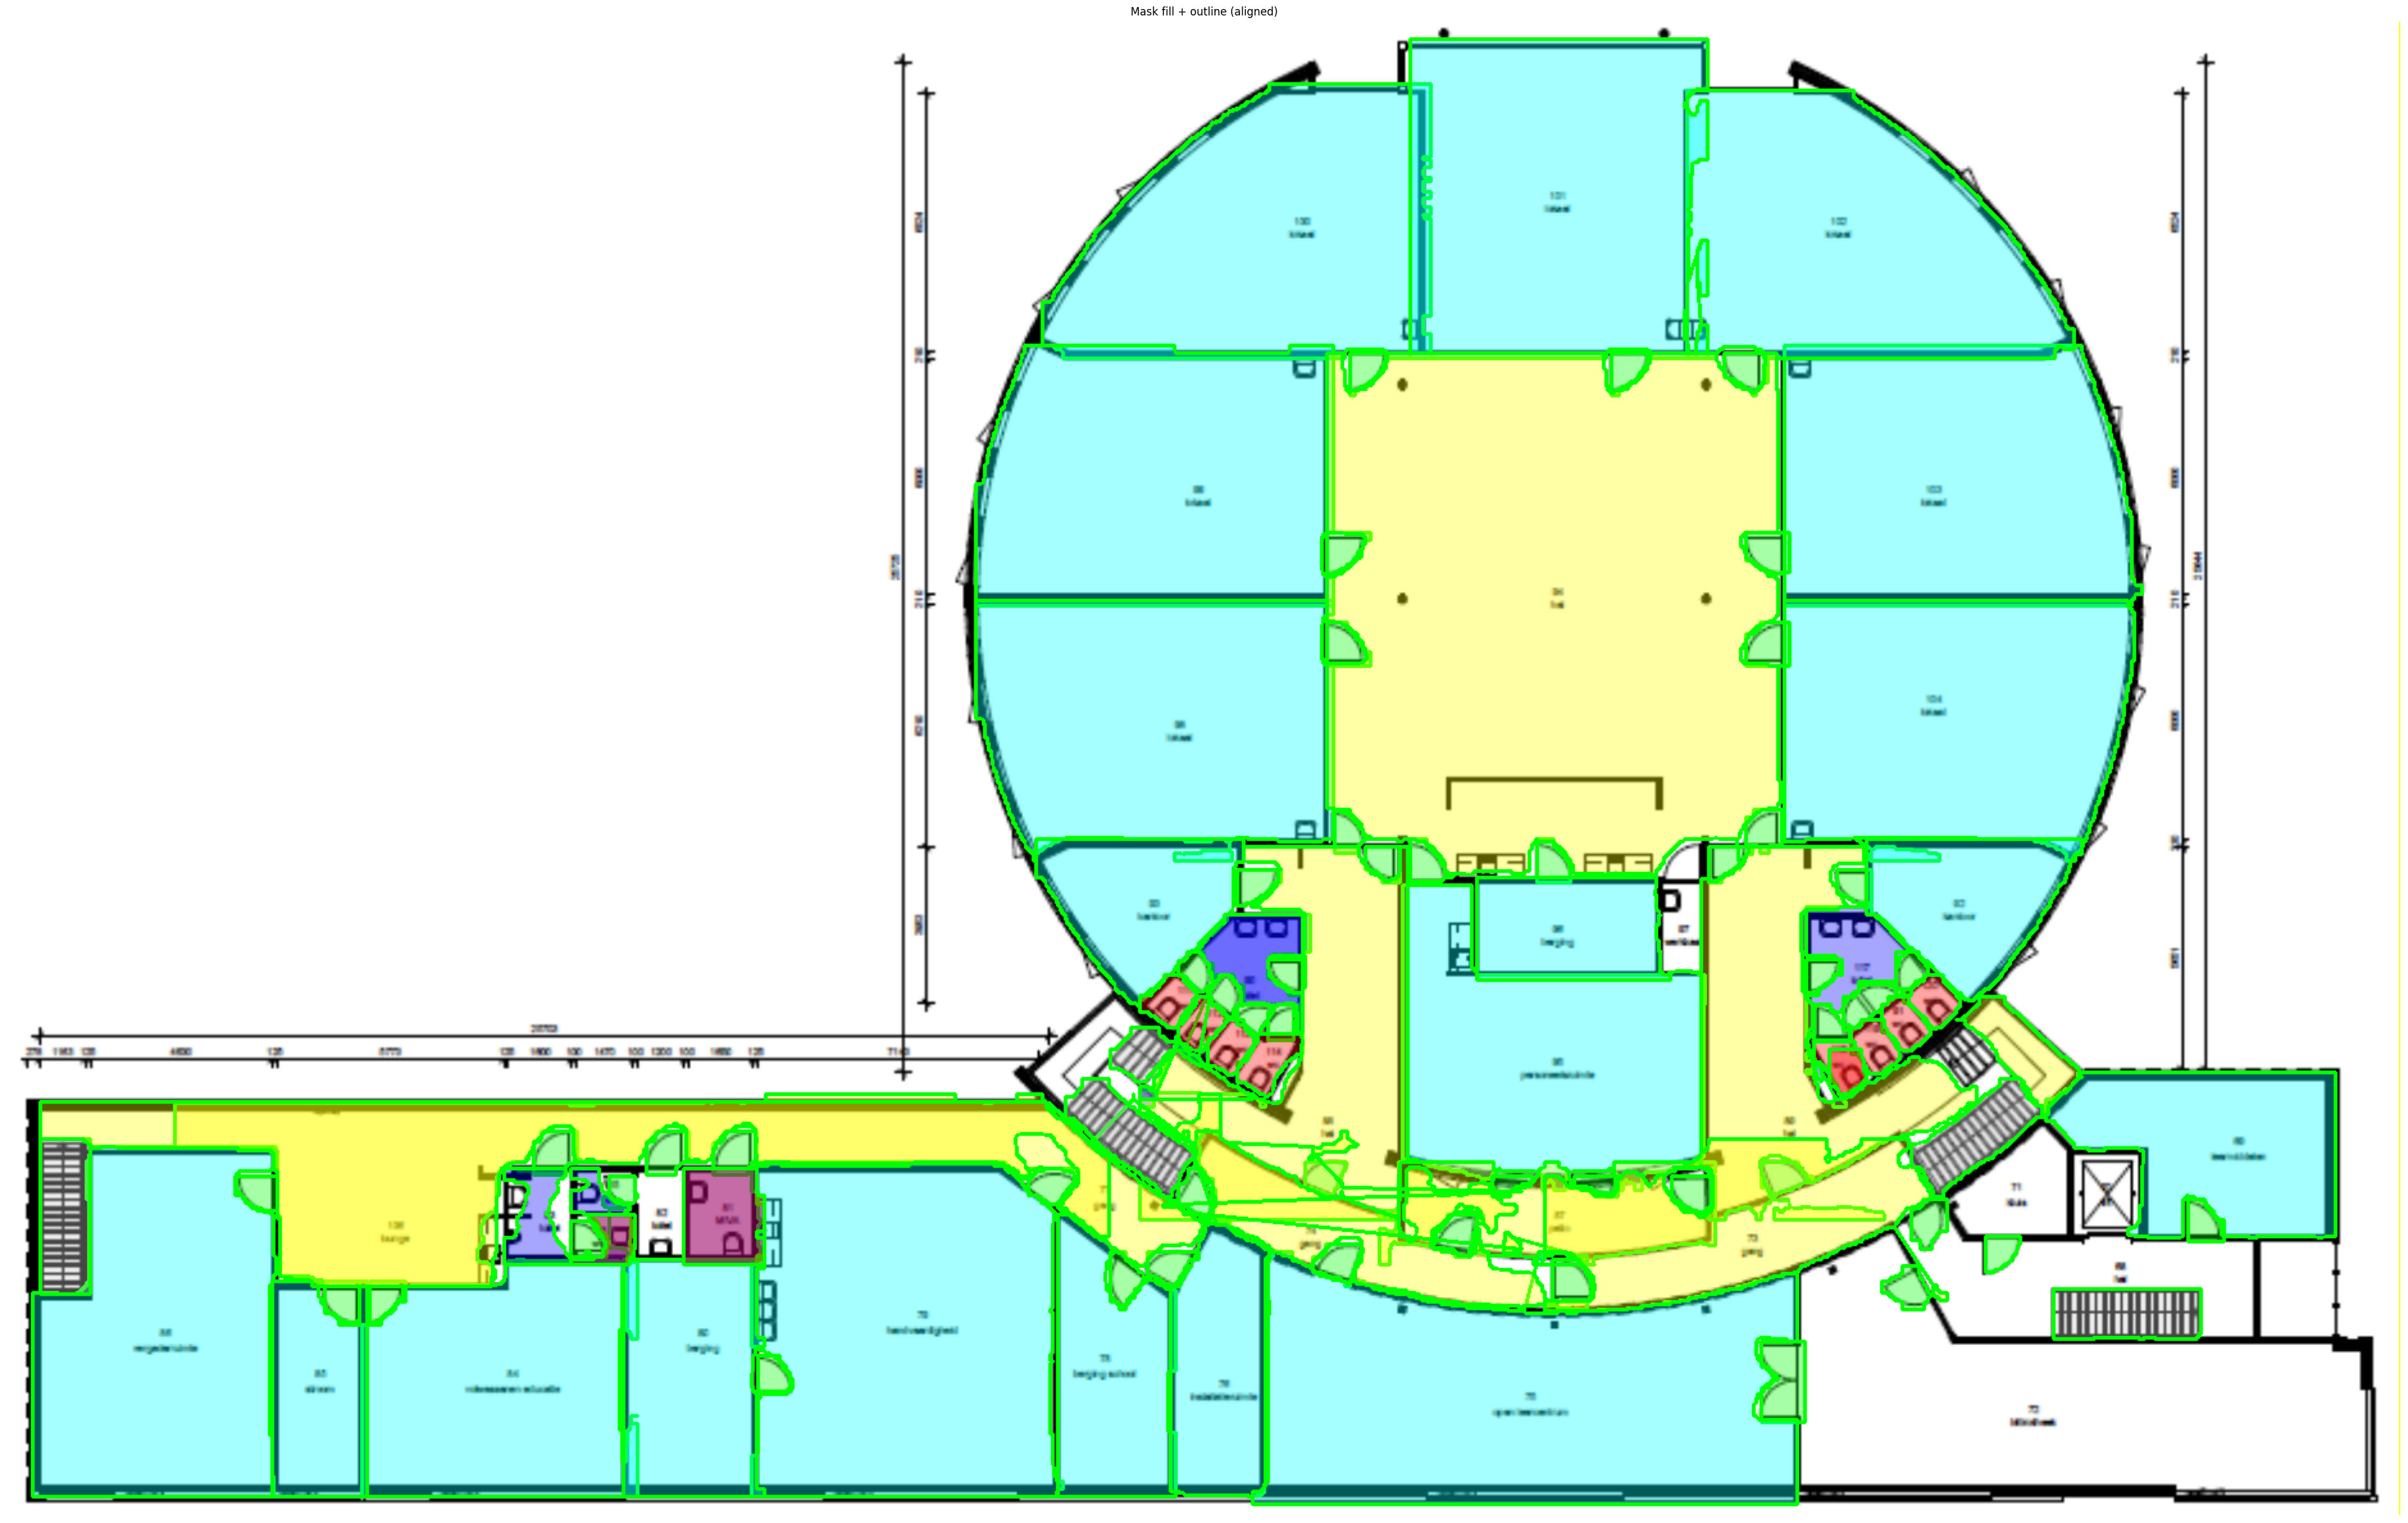

In [33]:
image_path = Path("images/Rondeel.png")

plt.figure(figsize=(48, 48))
plt.imshow(cv2.cvtColor(Detect_and_Overlay(image_path, imgsz=1280), cv2.COLOR_BGR2RGB))
plt.title("Mask fill + outline (aligned)")
plt.axis("off")
plt.show()